# 01. Analiza exploratorie a datelor (EDA)

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Scopul acestui notebook este să cunoaștem datele înainte de a lucra cu ele: ce conțin, ce lipsește, ce probleme de calitate au și cât de grea este legarea surselor între ele. Fiecare celulă de cod este precedată de o explicație a întrebării la care răspunde și urmată de interpretarea rezultatului. Fiecare secțiune se încheie cu o constatare, formulată ca rezultat, care va fi folosită în articol.

Folosim patru surse oficiale și publice. Nomenclatorul de stat al medicamentelor, publicat de Agenția Medicamentului și Dispozitivelor Medicale pe nomenclator.amdm.gov.md, se află în fișierul nomenclator_amdm.xls. Catalogul național de prețuri de producător, aprobat prin ordinele AMDM nr. Rg04-253 și Rg04-254 din 26.08.2026, se află în fișierul catalog_preturi_amdm.xls. Lista denumirilor comerciale de medicamente compensate din fondurile asigurării obligatorii, publicată de CNAM pe cnam.md la 21.08.2026, există în două versiuni, română și rusă, în fișierele cnam_compensate_RO.xlsx și cnam_compensate_RU.xlsx.

Notebook-ul citește doar din folderul data/raw, unde fișierele originale nu se modifică niciodată, prin modulele din folderul src. Cifrele citate în explicații corespund versiunii datelor identificate prin amprentele afișate în prima celulă. Pe o versiune nouă a surselor, codul rulează identic și graficele se actualizează singure, dar cifrele din explicații trebuie recitite din rezultate.

## 0. Pregătirea mediului

**Ce căutăm.** Pregătim instrumentele de lucru. Încărcăm bibliotecile, îi arătăm lui Python unde se află modulele proiectului, stabilim unde se salvează figurile și calculăm amprenta fiecărui fișier de date, ca să putem identifica exact versiunea datelor folosite.

In [1]:
import sys, hashlib
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib

# Rădăcina proiectului: funcționează fie că notebook-ul e pornit din notebooks/, fie din SD_utm/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))   # ca să putem importa ingest.py și clean.py

# Pasul 1 al pipeline-ului (citirea) și pasul 2 (curățarea de bază)
from ingest import load_nomenclator, load_catalog, load_cnam_ro, load_cnam_ru, RAW
from clean import clean_frame, clean_text, key_text, add_price_per_unit, equivalence_key, units_in_pack

# Folderul pentru figuri + stilul graficelor
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 60)

# Amprenta fiecărui fișier brut (primele 16 caractere din SHA-256)
for f in sorted(RAW.iterdir()):
    print(f"{f.name:32s} {hashlib.sha256(f.read_bytes()).hexdigest()[:16]}")

catalog_preturi_amdm.xls         c017270b9411ec00
cnam_compensate_RO.xlsx          e01545a639d5bb32
cnam_compensate_RU.xlsx          0facd3ddb307ecb9
nomenclator_amdm.xls             929f58c9f385699a


**Ce am obținut.** Avem numele celor patru fișiere de date și, lângă fiecare, amprenta lui. Amprenta, numită hash, este un cod calculat din întregul conținut al fișierului. Același fișier dă mereu același cod, pe orice calculator, iar orice modificare, oricât de mică, schimbă complet codul. Dacă cineva rulează notebook-ul și obține alte amprente, înseamnă că lucrează pe o altă versiune a datelor, nu că ar exista o eroare în cod.

## 1. Încărcarea datelor și inventarul surselor

**Ce căutăm.** Vrem să aflăm câte rânduri, adică produse, și câte coloane, adică caracteristici, are fiecare sursă. Citim toate valorile ca text, pentru că altfel programul ar transforma codul 0500090185 în numărul 500090185 și ar pierde zerourile din față, iar codul este exact cheia după care legăm sursele.

In [2]:
# Fiecare funcție load_* citește un fișier din data/raw și redenumește coloanele în formă scurtă, uniformă
raw = {"nomenclator": load_nomenclator(), "catalog": load_catalog(),
       "cnam_ro": load_cnam_ro(), "cnam_ru": load_cnam_ru()}

# Tabel rezumativ: dimensiunea fiecărei surse
pd.DataFrame({k: {"rânduri": v.shape[0], "coloane": v.shape[1]} for k, v in raw.items()}).T

,rânduri,coloane
nomenclator,6242,20
catalog,3719,22
cnam_ro,2167,15
cnam_ru,2168,15


**Ce am obținut.** Nomenclatorul conține 6.242 de medicamente autorizate, descrise prin 20 de caracteristici. Catalogul de prețuri conține 3.719 produse și 22 de coloane, printre care prețurile de producător aprobate de AMDM.. Are mai puține produse decât Nomenclatorul, pentru că nu toate medicamentele autorizate au un preț aprobat. Lista CNAM are 2.167 de rânduri în versiunea română și 2.168 în versiunea rusă. Cele două ar trebui să fie aceeași listă tradusă, așa că diferența de un rând este un prim semnal de inconsistență, pe care îl verificăm în secțiunea 9.

La citire am descoperit și câteva particularități de structură, tratate în fișierul src/ingest.py. În Nomenclator, al doilea rând al foii conține doar numerotarea coloanelor, de la 0 la 19, și nu reprezintă un medicament, așa că l-am eliminat. Fișierele .xls au câte trei foi, dintre care două sunt goale. Fișierele CNAM au câte două foi, una pentru adulți și una pentru copii, cu o structură ușor diferită, deoarece la copii lipsește suma compensată pe cutie. În fișierul CNAM în limba rusă, titlurile coloanelor pentru ambalaj și pentru forma farmaceutică sunt inversate față de conținutul lor, așa că am denumit coloanele după conținutul real, nu după titlu.

## 2. Curățarea de bază

**Ce căutăm.** Verificăm dacă datele conțin zgomot invizibil, cum ar fi spații în plus, caractere tab sau valori de tipul undefined scrise în locul unei celule goale. Pentru calculator, cuvântul таблетки scris cu un spațiu la final este o formă farmaceutică diferită de același cuvânt fără spațiu. Aplicăm doar reparații care nu schimbă sensul datelor și numărăm câte valori distincte are un câmp înainte și după curățare.

In [3]:
# clean_frame: taie spațiile/tab-urile parazite și transformă „undefined”, „-”, gol -> valoare lipsă (NaN)
n  = clean_frame(raw["nomenclator"])
c  = add_price_per_unit(clean_frame(raw["catalog"]))   # + calculează prețul efectiv și prețul pe unitate
ro = clean_frame(raw["cnam_ro"])
ru = clean_frame(raw["cnam_ru"])

def n_unique_before_after(col, df_raw, df_clean):
    # câte valori distincte are coloana înainte și după curățare
    return df_raw[col].nunique(), df_clean[col].nunique()

pd.DataFrame({
    "forma (CNAM RU)": n_unique_before_after("forma", raw["cnam_ru"], ru),
    "forma (CNAM RO)": n_unique_before_after("forma", raw["cnam_ro"], ro),
    "divizare (Nomenclator)": n_unique_before_after("divizare", raw["nomenclator"], n),
    "statut_compensare (RU)": n_unique_before_after("statut_compensare", raw["cnam_ru"], ru),
}, index=["valori distincte înainte", "după curățare"]).T

,valori distincte înainte,după curățare
forma (CNAM RU),69,67
forma (CNAM RO),104,104
divizare (Nomenclator),344,324
statut_compensare (RU),3,3


**Ce am obținut.** Divizările din Nomenclator scad de la 344 la 324 de valori distincte, ceea ce înseamnă că 20 de categorii existau doar din cauza spațiilor și a caracterelor invizibile. Formele farmaceutice din lista în rusă scad de la 69 la 67. Formele din lista în română rămân 104, ceea ce ne arată că diferențele de acolo nu vin din spații, ci din abrevieri, de exemplu comp. film. în loc de comprimate filmate. Acestea vor fi tratate la pasul de normalizare.

**Constatare 2.** O parte din diversitatea aparentă a datelor este zgomot de redactare, nu informație reală.

## 3. Valori lipsă

**Ce căutăm.** Vrem să știm ce procent din fiecare coloană este gol, în fiecare sursă, pentru că o coloană goală în proporție de 95% nu poate fi folosită nici pentru analiză, nici pentru potrivire. Afișăm doar coloanele cu cel puțin o valoare lipsă, sub forma unei hărți de culori în care o celulă mai roșie înseamnă mai multe valori lipsă.

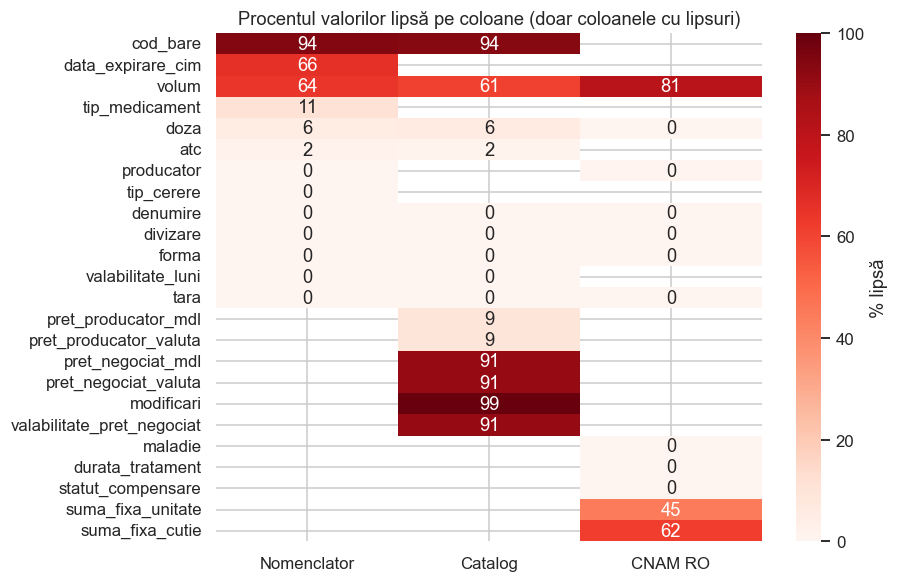

In [4]:
# Procentul de valori lipsă pe coloană, pentru fiecare sursă (excludem coloanele calculate de noi)
miss = pd.concat({k: v.isna().mean()*100 for k, v in {
    "Nomenclator": n,
    "Catalog": c.drop(columns=["tip_pret", "unitati", "pret_mdl", "pret_unitate_mdl"]),
    "CNAM RO": ro.drop(columns=["grup", "limba"])}.items()}, axis=1)
miss = miss[(miss > 0).any(axis=1)].sort_values("Nomenclator", ascending=False)   # doar coloanele cu lipsuri

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(miss, annot=True, fmt=".0f", cmap="Reds", cbar_kws={"label": "% lipsă"}, ax=ax, vmin=0, vmax=100)
ax.set_title("Procentul valorilor lipsă pe coloane (doar coloanele cu lipsuri)")
ax.set_xlabel(""); ax.set_ylabel("")
fig.savefig(FIG / "fig01_valori_lipsa.png"); plt.show()

**Ce am obținut.** Celulele albe cu valoarea 0 arată că denumirea, forma, divizarea și țara sunt practic complete, ceea ce este o condiție bună pentru potrivire. Codul de bare lipsește în aproximativ 94% din cazuri, deci nu poate servi drept cheie de legătură între surse. Data expirării certificatului lipsește la aproximativ două treimi din produse, pentru că în sursă apare scrisă ca undefined, așa că nu o vom folosi. Doza lipsește la aproximativ 6% din produse, mai ales la preparatele combinate și homeopate. Prețurile și sumele compensate au lipsuri mari, dar încă nu știm dacă acestea sunt erori sau au un sens, iar asta verificăm în celula următoare.

**Ce căutăm.** Verificăm dacă lipsurile din prețuri și din sumele compensate sunt întâmplătoare, adică erori, sau au o explicație. Ne întrebăm dacă fiecare produs din catalog are cel puțin un preț și dacă lipsa sumei compensate depinde de statutul de compensare.

In [5]:
# Există produse fără niciun preț? Sau cu ambele prețuri?
print("Catalog, produse cu AMBELE prețuri lipsă:", (c.pret_producator_mdl.isna() & c.pret_negociat_mdl.isna()).sum())
print("Catalog, produse cu AMBELE prețuri prezente:", (c.pret_producator_mdl.notna() & c.pret_negociat_mdl.notna()).sum())
print(c.tip_pret.value_counts().to_string())
print()
# Lipsa sumei compensate, separat pentru medicamentele integral și parțial compensate
print("CNAM, lipsa sumei fixe per unitate, pe statut de compensare (%):")
print((ro.groupby("statut_compensare").suma_fixa_unitate.apply(lambda s: s.isna().mean()*100)).round(1).to_string())
print()
print("Nomenclator, 'Data expirării CÎM' necunoscută (%):", round(n.data_expirare_cim.isna().mean()*100, 1))

Catalog, produse cu AMBELE prețuri lipsă: 0
Catalog, produse cu AMBELE prețuri prezente: 0
tip_pret
producator    3367
negociat       352

CNAM, lipsa sumei fixe per unitate, pe statut de compensare (%):
statut_compensare
integral compensat    95.6
parțial compensat      0.6

Nomenclator, 'Data expirării CÎM' necunoscută (%): 66.2


**Ce am obținut.** Niciun produs din catalog nu are ambele prețuri lipsă și niciunul nu le are pe amândouă. Fiecare produs are exact un preț: 3.367 au preț de producător și 352 au preț negociat, iar lipsurile de 91% și de 9% din harta de mai sus se completează reciproc. De aceea am definit un singur preț efectiv, care este prețul negociat atunci când există și prețul de producător în rest. Suma compensată lipsește la 95,6% din medicamentele compensate integral și doar la 0,6% din cele compensate parțial. Explicația este simplă: atunci când statul plătește tot, nu este nevoie de o sumă fixă, deci lipsa are o semnificație și nu este o eroare.

**Constatare 3.** Câmpurile de identificare sunt complete, codul de bare nu poate fi folosit drept cheie, iar lipsurile din prețuri și din sumele compensate sunt structurale, nu erori.

## 4. Compoziția pieței

**Ce căutăm.** Vrem să vedem cum arată piața medicamentelor autorizate: câte produse sunt generice și câte originale, câte se eliberează pe rețetă și câte liber, și din ce țări provin. Ne interesează mai ales dacă informația despre tipul generic sau original este disponibilă pentru toate produsele, pentru că vrem să o folosim în analiză.

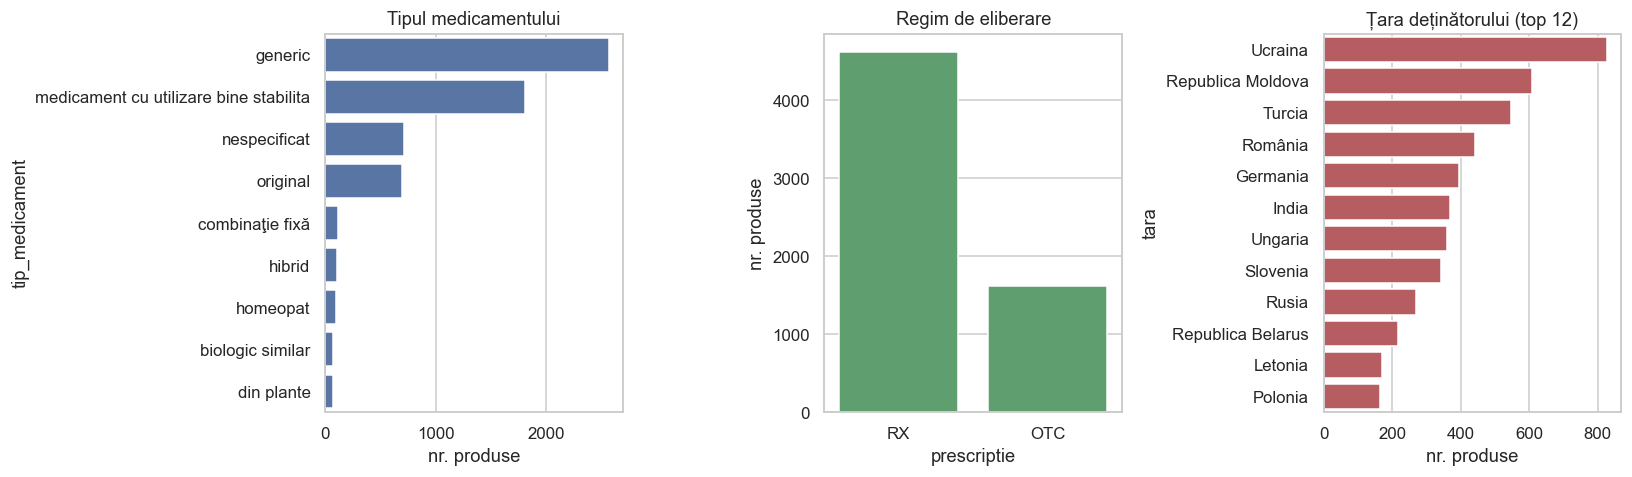

Țări distincte: 58 | DCI distincte: 1104 | coduri ATC: 1015 | denumiri comerciale: 3030


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# (a) tipul medicamentului; valorile „undefined” au devenit NaN la curățare -> le numim „nespecificat”
tm = n.tip_medicament.fillna("nespecificat").value_counts()
sns.barplot(x=tm.values, y=tm.index, ax=axes[0], color="#4C72B0"); axes[0].set_title("Tipul medicamentului"); axes[0].set_xlabel("nr. produse")
# (b) regimul de eliberare: RX = pe rețetă, OTC = liber
rx = n.prescriptie.value_counts()
sns.barplot(x=rx.index, y=rx.values, ax=axes[1], color="#55A868"); axes[1].set_title("Regim de eliberare"); axes[1].set_ylabel("nr. produse")
# (c) primele 12 țări ale deținătorilor
tara = n.tara.value_counts().head(12)
sns.barplot(x=tara.values, y=tara.index, ax=axes[2], color="#C44E52"); axes[2].set_title("Țara deținătorului (top 12)"); axes[2].set_xlabel("nr. produse")
fig.tight_layout(); fig.savefig(FIG / "fig02_compozitie_piata.png"); plt.show()

print("Țări distincte:", n.tara.nunique(), "| DCI distincte:", n.dci.nunique(), "| coduri ATC:", n.atc.nunique(), "| denumiri comerciale:", n.denumire.nunique())

**Ce am obținut.** Cele mai multe produse sunt generice, 2.563, urmate de medicamentele cu utilizare bine stabilită, 1.808, și de medicamentele originale, 693. Pentru 711 produse, adică aproximativ 11%, tipul nu este specificat. Aproximativ trei sferturi din produse se eliberează pe bază de rețetă, 4.619 față de 1.623 cu vânzare liberă. Piața este diversă, cu deținători din 58 de țări, dintre care cele mai multe produse vin din Ucraina, Republica Moldova, Turcia și România. Există 1.106 substanțe active, 1.020 de coduri ATC și 3.059 de denumiri comerciale distincte, deci aceeași substanță se vinde adesea sub mai multe denumiri.

**Constatare 4.** Comparația dintre generice și originale se poate face doar pe produsele pentru care tipul este specificat, adică aproximativ 89% din total. Categoria medicamentelor cu utilizare bine stabilită este a doua ca mărime și trebuie tratată separat.

## 5. Câte produse are fiecare substanță activă

**Ce căutăm.** Vrem să știm dacă există suficiente substanțe active cu multe produse echivalente. Dacă fiecare substanță ar avea un singur producător, pacientul nu ar avea între ce alege, iar aplicația din teză nu ar avea ce compara. Excludem mențiunea Combinaţie, care nu este o substanță reală.

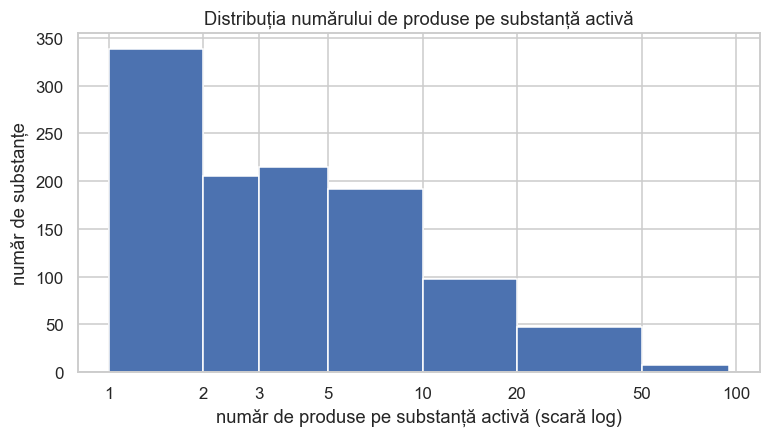

Substanțe active (fără combinații): 1101
  cu ≥3 produse: 558  |  cu >10 produse: 130
Top 10:
dci
ibuprofenum                 94
rivaroxabanum               77
pregabalinum                63
fluconazolum                61
bisoprololum                55
rosuvastatinum              53
diclofenacum                51
sildenafilum                49
glucosum                    48
acidum acetylsalicylicum    48


In [7]:
# key_text: litere mici, fără ®/™, diacritice unificate -> „Ibuprofenum” și „IBUPROFENUM” devin la fel
dci_key = key_text(n.dci)
dci_key = dci_key[~dci_key.str.startswith("combina", na=False)]   # scoatem „Combinaţie”
per_dci = dci_key.value_counts()                                   # nr. de produse pentru fiecare substanță

fig, ax = plt.subplots(figsize=(8, 4))
bins = [1, 2, 3, 5, 10, 20, 50, per_dci.max()+1]
ax.hist(per_dci, bins=bins, color="#4C72B0", edgecolor="white")
ax.set_xscale("log"); ax.set_xticks([1,2,3,5,10,20,50,100]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("număr de produse pe substanță activă (scară log)"); ax.set_ylabel("număr de substanțe")
ax.set_title("Distribuția numărului de produse pe substanță activă")
fig.savefig(FIG / "fig03_produse_per_dci.png"); plt.show()

print(f"Substanțe active (fără combinații): {len(per_dci)}")
print(f"  cu ≥3 produse: {(per_dci>=3).sum()}  |  cu >10 produse: {(per_dci>10).sum()}")
print("Top 10:"); print(per_dci.head(10).to_string())

**Ce am obținut.** Graficul arată că majoritatea substanțelor au doar unul sau două produse, dar există și un număr important de substanțe cu zeci de produse. Din cele 1.101 substanțe active, 558 au cel puțin trei produse, iar 130 au mai mult de zece. Pe primul loc se află ibuprofenul, cu 94 de produse diferite, urmat de rivaroxaban, cu 77, și de pregabalin, cu 63.

**Constatare 5.** Există câteva sute de substanțe pentru care pacientul poate alege între mai multe produse, iar acestea sunt grupurile în care compararea echivalentelor are sens.

## 6. Prețurile de producător

Prețurile din Catalog sunt prețuri de producător, notate în sursă ex works, adică prețul la care producătorul își vinde medicamentul, înainte ca acesta să ajungă în farmacie. Prețul plătit de pacient este mai mare, pentru că peste prețul de producător se adaugă costurile de import și transport, adaosul distribuitorului, adaosul farmaciei și taxele. Din acest motiv, cifrele absolute din această secțiune nu arată cât plătește pacientul, ci cum își stabilesc producătorii prețurile. Comparațiile relative, cum este raportul dintre prețul cel mai mare și cel mai mic dintr-un grup de echivalență, își păstrează sensul, deoarece adaosurile se aplică în mare parte proporțional cu prețul. Prețurile reale din farmacii vor fi colectate în partea a doua a tezei.

**Ce căutăm.** Vrem să aflăm în ce monedă sunt aprobate prețurile, dacă putem calcula prețul pe unitate pentru toate produsele și cât de mari sunt, în general, diferențele de preț. Prețul pe ambalaj nu poate fi comparat direct, pentru că o cutie poate avea 10 comprimate, iar alta 30, așa că împărțim prețul la numărul de unități din ambalaj. De exemplu, divizarea N10x3 înseamnă 30 de unități. Trebuie spus că la formele lichide unitatea este un flacon sau o fiolă, iar acestea au volume diferite, deci acolo prețul pe unitate nu este încă comparabil și va fi corectat la normalizare.

In [8]:
print("Valuta prețului:"); print(c.valuta.value_counts().to_string())

# Divizările pe care nu le-am putut transforma în număr de unități (ex. truse „N1 + N1”)
print(f"\nDivizări care nu au putut fi interpretate: {c.unitati.isna().sum()} din {len(c)} ({c.unitati.isna().mean():.1%})")
print(c.loc[c.unitati.isna(), "divizare"].value_counts().head(6).to_string())

# Statistici descriptive: minim, cuartile, percentile mari, maxim
c[["pret_mdl", "pret_unitate_mdl"]].describe(percentiles=[.25,.5,.75,.95,.99]).round(2)

Valuta prețului:
valuta
EUR    1956
USD    1351
MDL     383
RUB      21
RON       8

Divizări care nu au putut fi interpretate: 67 din 3719 (1.8%)
divizare
N1 + N1    13
N1 + 1      8
N1+N1       7
N1+1        6
N3 + N3     3
N5 + 5      2


,pret_mdl,pret_unitate_mdl
count,3719.00,3652.00
mean,1133.91,656.49
std,7377.00,6010.90
min,2.24,0.12
25%,35.88,2.27
50%,68.49,7.10
75%,161.30,41.48
95%,2487.54,789.14
99%,30067.51,15369.80
max,165674.63,165674.63


**Ce am obținut.** Prețurile sunt aprobate mai ales în euro, 1.956 de produse, și în dolari, 1.351, iar doar 383 sunt aprobate direct în lei. Catalogul oferă însă pentru fiecare produs și prețul echivalent în lei, pe care îl folosim ca toate prețurile să fie comparabile. Pentru 67 de produse, adică 1,8%, nu am putut calcula numărul de unități, deoarece sunt truse compuse, de exemplu o pulbere împreună cu solventul ei, și le lăsăm deoparte la analiza pe unitate. Prețul de producător median al unui ambalaj este de aproximativ 68 de lei, dar media este de aproximativ 1.134 de lei, de peste 16 ori mai mare. Atunci când media este mult peste mediană, înseamnă că un număr mic de produse foarte scumpe trage media în sus. Prețul de producător maxim ajunge la aproximativ 165.675 de lei, iar prețul median pe unitate, adică pentru un comprimat sau o fiolă, este de aproximativ 7 lei.

**Ce căutăm.** Vrem să vedem forma distribuției prețurilor și să aflăm ce produse formează grupul prețurilor foarte mari. Folosim scara logaritmică, în care fiecare pas pe axă înseamnă o valoare de zece ori mai mare, pentru că altfel produsele ieftine s-ar aduna toate într-o singură bară. Comparăm separat formele solide, cum sunt comprimatele și capsulele, cu celelalte forme.

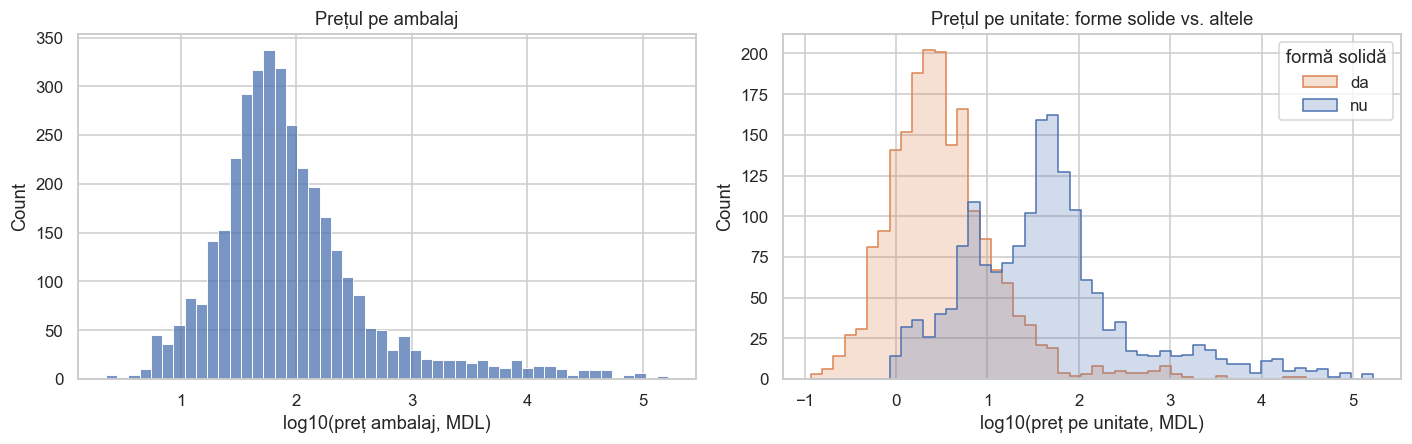

Cele mai scumpe 60 de produse, prima literă a codului ATC (grupa anatomică):
atc
L    34
B    10
V    10
C     2
A     2
M     1
J     1


In [9]:
# Marcăm formele solide: la ele prețul pe unitate (per comprimat/capsulă) e direct comparabil
SOLIDE = r"comprimat|capsul|drajeu|supozitor|ovul|plic"
c["solid"] = key_text(c.forma).str.contains(SOLIDE, na=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# (a) prețul pe ambalaj, pe scară log10: 1 = 10 lei, 2 = 100 lei, 3 = 1.000 lei ...
sns.histplot(np.log10(c.pret_mdl.dropna()), bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("log10(preț ambalaj, MDL)"); axes[0].set_title("Prețul pe ambalaj")
# (b) prețul pe unitate, separat pentru forme solide și celelalte
sns.histplot(data=c.dropna(subset=["pret_unitate_mdl"]).assign(x=lambda d: np.log10(d.pret_unitate_mdl)),
             x="x", hue="solid", bins=50, ax=axes[1], element="step", stat="count")
axes[1].set_xlabel("log10(preț pe unitate, MDL)"); axes[1].set_title("Prețul pe unitate: forme solide vs. altele")
axes[1].legend(title="formă solidă", labels=["da", "nu"])
fig.tight_layout(); fig.savefig(FIG / "fig04_distributie_preturi.png"); plt.show()

# Ce produse sunt în coada din dreapta? Prima literă ATC = grupa anatomică principală
top = c.nlargest(60, "pret_mdl")
print("Cele mai scumpe 60 de produse, prima literă a codului ATC (grupa anatomică):")
print(top.atc.str[0].value_counts().to_string())

**Ce am obținut.** Pe scara logaritmică, prețurile pe ambalaj formează o curbă în formă de clopot, aproximativ simetrică, centrată în jurul valorii 1,8, ceea ce corespunde unui preț de producător de aproximativ 65 de lei. Aceasta înseamnă că logaritmul prețului are o distribuție apropiată de cea normală, o proprietate utilă pentru modelare. Graficul din dreapta arată că formele solide sunt concentrate la prețuri mici pe unitate, în timp ce fiolele și flacoanele sunt mai scumpe și mai împrăștiate. Dintre cele mai scumpe 60 de produse, 34 aparțin clasei ATC L, care cuprinde medicamentele oncologice și imunomodulatoare, 10 aparțin clasei B, a medicamentelor pentru sânge, și 10 clasei V, din care fac parte de exemplu preparatele radiofarmaceutice. Prețurile foarte mari reflectă deci realitatea pieței și nu sunt erori.

**Constatare 6.** Prețurile de producător se întind pe cinci ordine de mărime și sunt puternic asimetrice, dar pe scară logaritmică devin aproximativ simetrice. De aceea, în etapa de modelare vom lucra cu logaritmul prețului.

## 7. Dispersia prețurilor în grupurile de echivalență

**Ce căutăm.** Vrem să aflăm cât de mult diferă prețul între medicamentele echivalente, adică între produsele cu aceeași substanță activă, aceeași doză și aceeași formă, ceea ce corespunde echivalenței de nivel 1 din propunerea de teză. Pentru fiecare grup cu cel puțin două produse calculăm raportul dintre prețul cel mai mare și cel mai mic pe unitate. Un raport de 1 înseamnă că toate produsele au același preț de producător, iar un raport de 3 înseamnă că produsul cel mai scump are un preț de producător de trei ori mai mare decât cel mai ieftin. Deocamdată grupurile sunt formate pe baza textului doar curățat, nu și normalizat, așa că unele echivalente reale nu ajung în același grup, iar cifrele obținute sunt o estimare prudentă.

In [10]:
# Cheia grupului: „dci | doză | formă” (pentru combinații fără DCI: codul ATC complet)
c["grup_echiv"] = equivalence_key(c)

# Pentru fiecare grup: nr. produse, nr. deținători distincți, preț min / max / median pe unitate
grp = (c.dropna(subset=["pret_unitate_mdl"])
         .groupby("grup_echiv")
         .agg(n=("cod", "size"), detinatori=("detinator", "nunique"), solid=("solid", "first"),
              pmin=("pret_unitate_mdl", "min"), pmax=("pret_unitate_mdl", "max"), pmed=("pret_unitate_mdl", "median")))
grp = grp[grp.n >= 2].assign(raport=lambda d: d.pmax / d.pmin)   # doar grupurile în care avem ce compara

rez = pd.DataFrame({
    "toate formele": [len(grp), grp.raport.median(), grp.raport.quantile(.9), (grp.raport >= 2).mean()],
    "doar forme solide": [grp.solid.sum(), grp[grp.solid].raport.median(), grp[grp.solid].raport.quantile(.9), (grp[grp.solid].raport >= 2).mean()],
}, index=["nr. grupuri (≥2 produse)", "raport max/min, mediană", "raport max/min, percentila 90", "% grupuri cu raport ≥ 2x"]).round(2)
rez

,toate formele,doar forme solide
nr. grupuri (≥2 produse),680.00,358.00
"raport max/min, mediană",1.34,1.31
"raport max/min, percentila 90",2.84,2.43
% grupuri cu raport ≥ 2x,0.21,0.18


**Ce am obținut.** Avem 680 de grupuri de echivalență cu cel puțin două produse, dintre care 358 sunt de forme solide. Raportul median este 1,34, ceea ce înseamnă că, în grupul obișnuit, produsul cel mai scump are un preț de producător cu aproximativ o treime mai mare decât cel mai ieftin. În 10% din grupuri diferența este de aproape trei ori sau mai mare, iar în 21% din grupuri, adică aproximativ unul din cinci, produsul cel mai scump are un preț de producător de peste două ori mai mare. La formele solide, unde comparația este cea mai corectă, valorile sunt puțin mai mici, cu o mediană de 1,31 și 18% din grupuri peste pragul de două ori, dar rămân semnificative.

**Ce căutăm.** Vrem să vedem cum sunt distribuite rapoartele între grupuri și care sunt cazurile extreme. Acestea trebuie verificate, pentru că pot reprezenta diferențe reale de preț sau pot fi efecte ale modului în care sunt înregistrate datele.

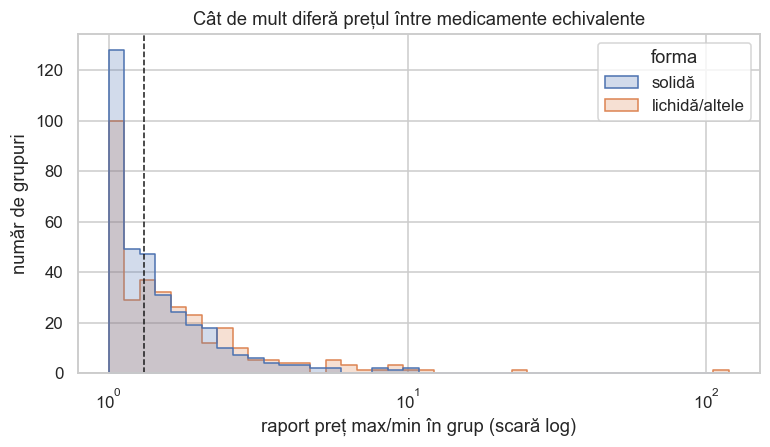

Grupurile cu cea mai mare dispersie (de verificat manual):


,n,detinatori,pmin,pmax,raport
grup_echiv,,,,,
doxorubicinum | 2 mg/ml | concentrat pentru soluție perfuzabilă,2,2,46.50,5524.81,118.81
lactulosum | 667 mg/ml | soluție orală,6,2,7.09,166.85,23.55
docetaxelum | 20 mg/ml | concentrat pentru soluție perfuzabilă,7,3,169.91,1940.06,11.42
rosuvastatinum | 5 mg | comprimate filmate,6,6,1.13,12.04,10.68
loperamidum | 2 mg | capsule,5,4,1.13,11.80,10.45
ketoconazolum | 20 mg/ml | șampon,4,2,5.26,51.42,9.78
piracetamum | 200 mg/ml | soluție injectabilă,4,3,1.93,17.86,9.23
irinotecanum | 20 mg/ml | concentrat pentru soluție perfuzabilă,6,4,131.85,1217.60,9.23


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=grp.assign(forma=np.where(grp.solid, "solidă", "lichidă/altele")), x="raport", hue="forma",
             log_scale=True, bins=40, element="step", ax=ax)
ax.axvline(grp[grp.solid].raport.median(), ls="--", c="k", lw=1)   # linia punctată = mediana la forme solide
ax.set_xlabel("raport preț max/min în grup (scară log)"); ax.set_ylabel("număr de grupuri")
ax.set_title("Cât de mult diferă prețul între medicamente echivalente")
fig.savefig(FIG / "fig05_dispersie_grupuri.png"); plt.show()

print("Grupurile cu cea mai mare dispersie (de verificat manual):")
grp.sort_values("raport", ascending=False).head(8)[["n", "detinatori", "pmin", "pmax", "raport"]].round(2)

**Ce am obținut.** Histograma arată că majoritatea grupurilor au rapoarte apropiate de 1, adică prețuri apropiate, dar distribuția are o coadă lungă spre dreapta, mai ales la formele lichide. Cazurile extreme, cum sunt doxorubicina cu un raport de aproximativ 119, lactuloza cu aproximativ 24 și docetaxelul cu aproximativ 11, sunt toate forme lichide. Aici diferența vine cel mai probabil din faptul că flacoanele au volume diferite, de exemplu 5 ml față de 100 ml, iar prețul pe flacon nu este comparabil, așa că efectul ar trebui să dispară după normalizarea pe cantitatea de substanță. Rosuvastatina de 5 mg sub formă de comprimate filmate apare însă și ea printre cazurile extreme, cu prețuri de producător între 1,13 și 12,04 lei pe comprimat, adică de aproximativ zece ori mai mult. Aici comparația este corectă, pentru că un comprimat se compară cu un comprimat, deci diferența este reală.

**Constatare 7.** Dispersia prețurilor între medicamentele echivalente este semnificativă. Cazurile cu diferențe de peste douăzeci de ori apar la formele lichide și se datorează în mare parte volumelor diferite, ceea ce justifică pasul de normalizare. La formele solide, diferențele de până la zece ori sunt reale. Fiind prețuri de producător, aceste rapoarte descriu diferențele dintre prețurile stabilite de producători, nu diferențele exacte plătite de pacient în farmacie.

### 7.1. O primă privire asupra ipotezei de concurență

**Ce căutăm.** Vrem să aflăm dacă grupurile cu mai mulți deținători, adică cu mai mulți producători concurenți, au o dispersie diferită a prețurilor. Raportul dintre prețul maxim și cel minim nu are unitate de măsură, deci putem compara grupuri de substanțe diferite. Folosim doar formele solide, unde comparația este corectă, și împărțim grupurile după numărul de deținători în patru categorii: unul, doi, trei sau patru, cinci sau mai mulți.

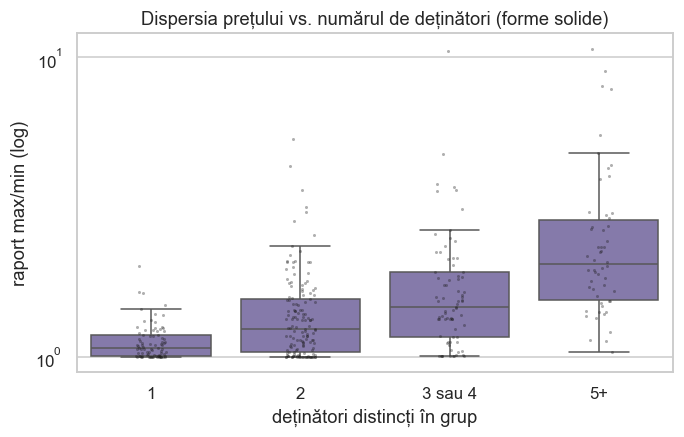

               count  median
nr_detinatori               
1                 84    1.07
2                143    1.24
3 sau 4           77    1.46
5+                54    2.04
Corelație Spearman (deținători, raport): 0.553


In [12]:
g2 = grp[grp.solid].copy()
g2["nr_detinatori"] = pd.cut(g2.detinatori, [0, 1, 2, 4, 100], labels=["1", "2", "3 sau 4", "5+"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=g2, x="nr_detinatori", y="raport", ax=ax, color="#8172B2", showfliers=False)   # cutia = 50% din grupuri
sns.stripplot(data=g2, x="nr_detinatori", y="raport", ax=ax, color="k", size=2, alpha=.35)      # fiecare punct = un grup
ax.set_yscale("log"); ax.set_xlabel("deținători distincți în grup"); ax.set_ylabel("raport max/min (log)")
ax.set_title("Dispersia prețului vs. numărul de deținători (forme solide)")
fig.savefig(FIG / "fig06_concurenta_dispersie.png"); plt.show()

print(g2.groupby("nr_detinatori", observed=True).raport.agg(["count", "median"]).round(2))
# Spearman: corelație pe ranguri, de la -1 la +1; nu presupune o relație liniară
print("Corelație Spearman (deținători, raport):", round(g2[["detinatori", "raport"]].corr("spearman").iloc[0, 1], 3))

**Ce am obținut.** Fiecare punct din grafic reprezintă un grup de echivalență, iar dreptunghiul cuprinde jumătatea din mijloc a grupurilor, cu mediana marcată prin linia din interior. Mediana raportului crește constant odată cu numărul de deținători, de la 1,07 pentru grupurile cu un singur deținător la 1,24 pentru cele cu doi, 1,46 pentru cele cu trei sau patru și 2,04 pentru cele cu cinci sau mai mulți. Cu alte cuvinte, acolo unde există mai mulți concurenți, prețurile sunt mai împrăștiate, nu mai apropiate. Coeficientul de corelație Spearman, care măsoară legătura dintre două variabile pe o scară de la minus unu la unu, este 0,55, ceea ce indică o legătură pozitivă de intensitate medie spre puternică. Trebuie totuși să fim atenți la interpretare, pentru că o parte din efect este mecanică: cu cât un grup are mai multe produse, cu atât prețul cel mai mare și cel mai mic se depărtează, chiar dacă prețurile ar fi stabilite la întâmplare. Pentru a separa efectul real de cel mecanic avem nevoie de un model, iar acesta este rolul modelării probabiliste din săptămânile următoare.

**Constatare 7.1.** Dispersia prețurilor crește odată cu numărul de deținători, cu o corelație de 0,55. Analiza exploratorie arată că întrebarea merită pusă, iar răspunsul îl va da modelul.

## 8. Cât de greu este să legăm sursele între ele

**Ce căutăm.** Vrem să aflăm cât de ușor se leagă sursele între ele. Catalogul și Nomenclatorul au amândouă codul medicamentului, așa că legătura dintre ele ar trebui să fie directă. Lista CNAM nu are acest cod, deci singura cale este compararea denumirii, a dozei și a formei. Măsurăm câte rânduri din lista CNAM își găsesc perechea exactă în Nomenclator la niveluri crescânde de curățare și care dintre câmpuri împiedică potrivirea.

Catalog → Nomenclator după cod: 3653 din 3719 (98.2%)


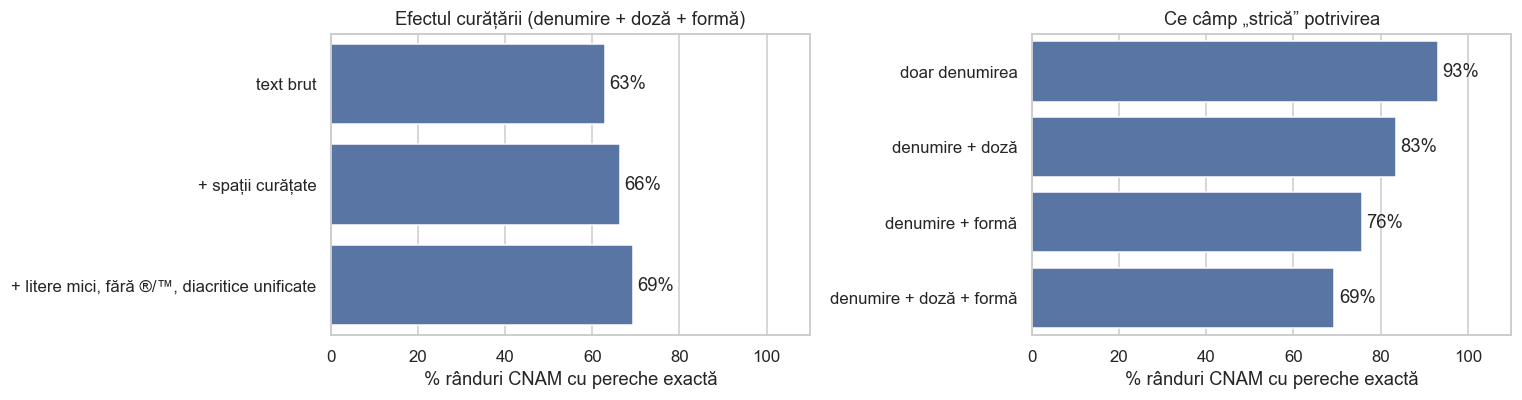

In [13]:
# (1) Legătura prin cod: Catalog -> Nomenclator
print("Catalog → Nomenclator după cod:", c.cod.isin(n.cod).sum(), "din", len(c), f"({c.cod.isin(n.cod).mean():.1%})")

def match_rate(a, b, cols, f):
    # proporția rândurilor din a care au în b un rând cu EXACT aceleași valori pe coloanele cols (după transformarea f)
    ka = pd.Series(list(zip(*[f(a[x]) for x in cols])))
    kb = set(zip(*[f(b[x]) for x in cols]))
    return ka.isin(kb).mean()

ident = lambda s: s.astype(str)       # fără nicio transformare
cols = ["denumire", "doza", "forma"]
# (2) Efectul curățării asupra potrivirii
niveluri = pd.Series({
    "text brut": match_rate(raw["cnam_ro"], raw["nomenclator"], cols, ident),
    "+ spații curățate": match_rate(ro, n, cols, clean_text),
    "+ litere mici, fără ®/™, diacritice unificate": match_rate(ro, n, cols, key_text),
})
# (3) Ce câmp strică potrivirea: adăugăm câmpurile pe rând
campuri = pd.Series({
    "doar denumirea": match_rate(ro, n, ["denumire"], key_text),
    "denumire + doză": match_rate(ro, n, ["denumire", "doza"], key_text),
    "denumire + formă": match_rate(ro, n, ["denumire", "forma"], key_text),
    "denumire + doză + formă": match_rate(ro, n, cols, key_text),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, s, t in [(axes[0], niveluri, "Efectul curățării (denumire + doză + formă)"), (axes[1], campuri, "Ce câmp „strică” potrivirea")]:
    sns.barplot(x=s.values*100, y=s.index, ax=ax, color="#4C72B0")
    for i, v in enumerate(s.values): ax.text(v*100 + 1, i, f"{v:.0%}", va="center")
    ax.set_xlim(0, 110); ax.set_xlabel("% rânduri CNAM cu pereche exactă"); ax.set_ylabel(""); ax.set_title(t)
fig.tight_layout(); fig.savefig(FIG / "fig07_rata_potrivire_cnam.png"); plt.show()

**Ce am obținut.** Legătura dintre Catalog și Nomenclator prin cod reușește pentru 3.653 din 3.719 produse, adică 98,2%. Pentru aceste perechi știm sigur care este răspunsul corect. Totuși, denumirea, forma, doza și divizarea sunt scrise identic în cele două surse în 99,9% din perechi, pentru că ambele provin de la AMDM, așa că singure nu pot testa algoritmii de potrivire. Graficul din stânga arată că, pe textul neprelucrat, doar 63% din rândurile CNAM își găsesc perechea exactă în Nomenclator. Eliminarea spațiilor ridică procentul la 66%, iar trecerea la litere mici și eliminarea simbolurilor de marcă îl ridică la 69%. Curățarea ajută, dar nu rezolvă problema, pentru că aproape o treime din rânduri rămân nelegate. Graficul din dreapta arată de unde vine problema. Dacă folosim doar denumirea, 93% din rânduri găsesc o pereche, însă procentul scade la 83% când adăugăm doza, la 76% când adăugăm forma și la 69% când le folosim pe toate trei. Denumirile se potrivesc deci aproape întotdeauna, iar doza și forma, scrise diferit în cele două surse, sunt cele care împiedică potrivirea.

**Ce căutăm.** Vrem să vedem concret cum sunt scrise diferit doza și forma în cele două surse. Pentru doze înlocuim fiecare număr cu cifra 9, astfel încât să vedem modul de scriere, nu valorile propriu-zise.

In [14]:
print("Cum e scrisă aceeași informație în surse diferite:\n")
print("Forme, CNAM RO (top 12):"); print(ro.forma.value_counts().head(12).to_string())

# Șablonul dozei: „500 mg” -> „9 mg”, „10 mg/5 ml” -> „9 mg/9 ml”
pat = lambda s: s.fillna("").str.replace(r"\d+([.,]\d+)?", "9", regex=True)
print("\nȘabloane de doză, Nomenclator vs CNAM (9 = orice număr):")
pd.concat([pat(n.doza).value_counts().head(8).rename("Nomenclator"),
           pat(ro.doza).value_counts().head(8).rename("CNAM RO")], axis=1).fillna(0).astype(int)

Cum e scrisă aceeași informație în surse diferite:

Forme, CNAM RO (top 12):
forma
comprimate filmate                                566
comprimate                                        535
capsule                                            97
comp. film.                                        93
soluţie injectabilă                                77
comprimate gastrorezistente                        69
soluţie perfuzabilă                                45
sirop                                              36
supozitoare                                        34
caps.                                              33
pulbere pentru soluţie injectabilă/perfuzabilă     33
pulb./sol. inj./perf.                              33

Șabloane de doză, Nomenclator vs CNAM (9 = orice număr):


,Nomenclator,CNAM RO
doza,,
9 mg,3021,1587
9 mg/ml,966,193
9 mg/9 mg,431,18
,346,0
9 mg/9 ml,287,97
9 mg/g,174,0
9 mg/9 mg/9 mg,149,0
9 g,105,49
9 mg + 9 mg,0,50


**Ce am obținut.** Lista CNAM scrie aceeași formă farmaceutică în două feluri. Apar, de exemplu, comprimate filmate de 566 de ori și comp. film. de 93 de ori, capsule de 97 de ori și caps. de 33 de ori, iar forma pulbere pentru soluţie injectabilă/perfuzabilă apare de 33 de ori și în forma abreviată pulb./sol. inj./perf. Nomenclatorul folosește doar denumirile complete. La combinațiile de substanțe, Nomenclatorul scrie doza sub forma 9 mg/9 mg, la 431 de produse, iar lista CNAM o scrie sub forma 9 mg + 9 mg, la 50 de produse, adică același lucru cu un alt separator. Unele moduri de scriere există doar într-una dintre surse, iar rândul fără model corespunde dozelor lipsă din Nomenclator.

**Constatare 8.** Aceasta este constatarea cea mai importantă pentru proiect. Legătura dintre lista CNAM și Nomenclator prin potrivire exactă de text reușește doar pentru 63 până la 69% din rânduri. Eșecurile nu vin din denumiri, ci din abrevieri și din convențiile diferite de scriere a dozei și a formei. Problema poate fi rezolvată, dar cere mai întâi normalizarea dozelor și a formelor, apoi o metodă de potrivire aproximativă care să cântărească indiciile, iar acesta este obiectul săptămânii a doua. Perechile dintre Catalog și Nomenclator, legate prin cod, au răspunsul corect cunoscut, dar textul lor este practic identic, așa că singure ar fi un test prea ușor. De aceea metoda va fi evaluată pe un set semisintetic, obținut prin introducerea în aceste perechi a variațiilor de scriere observate în lista CNAM, și pe un eșantion de înregistrări CNAM verificate manual.

## 9. Consistența versiunilor în română și în rusă ale listei CNAM

**Ce căutăm.** Vrem să verificăm dacă versiunile în română și în rusă ale listei CNAM conțin aceleași medicamente, așa cum ar fi normal pentru o traducere. Comparăm combinațiile formate din substanță, denumire, doză, divizare și grup de vârstă, care nu depind de limbă, și căutăm valori rămase netraduse.

In [15]:
k = ["dci", "denumire", "doza", "divizare", "grup"]   # câmpuri care nu se traduc
norm = lambda d: set(map(tuple, d[k].apply(lambda s: key_text(s).fillna("")).values))
A, B = norm(ro), norm(ru)

print(f"Rânduri: RO {len(ro)} | RU {len(ru)}")
print(f"Adulți: RO {(ro.grup=='adulti').sum()} | RU {(ru.grup=='adulti').sum()};  Copii: RO {(ro.grup=='copii').sum()} | RU {(ru.grup=='copii').sum()}")
print(f"Combinații comune: {len(A & B)} | doar în RO: {len(A - B)} | doar în RU: {len(B - A)}")
print("Rânduri duplicate identice: RO", ro.duplicated().sum(), "| RU", ru.duplicated().sum())
print("\nStatut compensare RU:"); print(ru.statut_compensare.value_counts().to_string())
print("\nExemple doar în RO:", sorted(A - B)[:3])
print("Exemple doar în RU:", sorted(B - A)[:3])

Rânduri: RO 2167 | RU 2168
Adulți: RO 1103 | RU 1107;  Copii: RO 1064 | RU 1061
Combinații comune: 1912 | doar în RO: 57 | doar în RU: 60
Rânduri duplicate identice: RO 8 | RU 8

Statut compensare RU:
statut_compensare
частично компенсируемый     1183
полностью компенсируемый     984
integral compensat             1

Exemple doar în RO: [('aceclofenacum', 'aceclofenac-lf', '100 mg', 'n10', 'copii'), ('amoxicillinum + acidum clavulanicum', '', '', '', 'copii'), ('amoxicillinum + acidum clavulanicum', 'amoklavin bid', '875 mg + 125 mg', 'n14x2', 'copii')]
Exemple doar în RU: [('', 'furosemid', '10 mg/ml', 'n10', 'adulti'), ('aceclofenacum', 'aceclofenac-lf', '100 mg', 'n10x2', 'copii'), ('aceclofenacum', 'aceclofenac-lf', '100 mg', 'n10x6', 'copii')]


**Ce am obținut.** Numărul de rânduri diferă între cele două versiuni: la adulți, versiunea română are 1.103 rânduri și cea rusă 1.107, iar la copii, versiunea română are 1.064 și cea rusă 1.061. Un număr de 1.912 combinații sunt comune, dar 57 apar doar în versiunea română și 60 doar în cea rusă. Exemplele arată că unele diferențe sunt de redactare, cum este cazul produsului Aceclofenac-LF, care are divizarea N10 în versiunea română, dar N10x2 și N10x6 în cea rusă, iar altele sunt rânduri incomplete, fără denumire sau fără substanță activă. Ambele versiuni conțin câte opt rânduri duplicate, iar în versiunea rusă un rând are statutul de compensare rămas scris în română.

**Constatare 9.** Versiunile în română și în rusă ale listei CNAM nu sunt identice. Din acest motiv, versiunea în română este sursa principală, fiind în aceeași limbă cu Nomenclatorul, iar versiunea în rusă va fi folosită doar pentru căutarea în limba rusă din aplicație.

## 10. Rezumatul analizei exploratorii și pașii următori

Analiza exploratorie a arătat că sursele au o structură neregulată, cu un rând de numerotare în Nomenclator și titluri de coloane inversate în lista în rusă, probleme pe care le-am tratat și documentat în etapa de citire. Spațiile și caracterele invizibile creau categorii false și au fost eliminate prin curățarea de bază. Lipsurile din prețuri și din sumele compensate s-au dovedit a avea o semnificație, ceea ce ne-a permis să definim un preț efectiv unic și să interpretăm lipsa sumei ca pe o compensare integrală. Aproximativ 11% din produse nu au specificat tipul, generic sau original, așa că această comparație se va face doar pe produsele etichetate. Prețurile de producător se întind pe cinci ordine de mărime, motiv pentru care vom modela logaritmul prețului.

Între medicamentele echivalente există o dispersie semnificativă a prețurilor, extremă la formele lichide, ceea ce cere normalizarea dozelor și a volumelor înainte de analiza finală. Dispersia crește odată cu numărul de deținători, o ipoteză pe care o vom testa cu un model capabil să separe efectul real de cel mecanic. Constatarea centrală este că lista CNAM se leagă de Nomenclator prin potrivire exactă doar în aproximativ 63% din cazuri, din cauza modului diferit de scriere a dozei și a formei, în timp ce Catalogul se leagă de Nomenclator prin cod în 98% din cazuri. Aceste perechi au răspunsul corect cunoscut, dar textul lor este practic identic, așa că vor servi drept bază pentru un set de evaluare semisintetic, completat de un eșantion de înregistrări CNAM verificate manual. În sfârșit, versiunile în română și în rusă ale listei CNAM nu coincid, așa că versiunea în română rămâne sursa principală. Toate analizele de preț din acest notebook se referă la prețurile de producător aprobate de AMDM, nu la prețurile finale din farmacii, care vor fi analizate în partea a doua a tezei.

În săptămâna a doua vom scrie modulul de normalizare, care va aduce dozele la unități standard și va înlocui abrevierile formelor farmaceutice cu denumirile complete. Apoi vom măsura din nou rata de potrivire și vom construi modelul probabilistic Fellegi Sunter, estimat prin algoritmul EM, pe care îl vom compara cu un model SVM și cu o rețea neuronală, evaluându-le pe perechile dintre Catalog și Nomenclator.

**Ce căutăm.** Salvăm datele curățate, astfel încât pașii următori ai pipeline-ului, adică normalizarea și potrivirea, să pornească de aici fără să repete citirea și curățarea.

In [16]:
out = ROOT / "data" / "interim"; out.mkdir(parents=True, exist_ok=True)
n.to_csv(out / "nomenclator_clean.csv", index=False)
c.to_csv(out / "catalog_clean.csv", index=False)
ro.to_csv(out / "cnam_ro_clean.csv", index=False)
ru.to_csv(out / "cnam_ru_clean.csv", index=False)
print("Salvat în", out)

Salvat în /Users/oleseapopa/Desktop/files/SD_utm/data/interim
